# Lab 3.2.2 — Prepare data for a machine learning model

**Hands-on objective:** perform the applicable data-preparation steps from section 3.2.1 and produce data for a supervised classification model.

This notebook follows **predict → act → observe → explain**. It is the only chronological workspace. Write in each empty answer cell before running the code that follows it. Open `learning_log.md` only when the final checkpoint directs you there.

## Learning agreement and perimeter

- Code provides evidence; your explanation provides the learning.
- Open hints progressively and only after making an attempt.
- After splitting, inspect feature values from training data only.
- The final supplied section trains one fixed model for later exercises, but this lab does **not** calculate metrics, tune the model, compare models, or claim production readiness.
- The dataset contains historical demographic and financial-status fields. Using them here supports a bounded educational benchmark; it does not endorse real-world profiling.

You will finish with four handoff artifacts, not with a performance score.

### How the learning tasks work

A **STOP** asks you to explain a concept or predict what the next output will show. Write ordinary language in the answer cell; exact jargon is not required when your meaning is clear. If a code cell asks you to enter a value, the preceding text lists every setting, its purpose, and the required Python form. Internal strings used only for record-keeping are supplied—you are not expected to guess them.

Useful terms are introduced where they first appear. You can also use the plain-language glossary in `README.md` and the field explanations in `data/DATA_DICTIONARY.md`.

In [1]:
# Preflight: this cell should run without edits.
import hashlib
import json
import platform
import sys
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

LAB_ROOT = Path.cwd()
RAW_DATA_PATH = LAB_ROOT / "data" / "raw" / "bank-additional-full.csv"
SOURCE_SHA256 = "74ADFC578BF77A7FF4BB1BA4A9F8709D9E3C6907342959C2C8416847E0AFB4D8"

print(f"Python: {platform.python_version()}")
print(f"pandas: {pd.__version__}")
print(f"scikit-learn: {sklearn.__version__}")

Python: 3.14.4
pandas: 3.0.0
scikit-learn: 1.9.0


## 1. Confirm what the dataset contains and where it came from

The raw file is UCI's `bank-additional-full.csv`, preserved unchanged. It represents historical direct-marketing calls by a Portuguese bank from May 2008 through November 2010. The target `y` records whether the client subscribed to a term deposit. Because the records come from one country, institution, period, product, and campaign process, this teaching dataset is not evidence that the same patterns represent contemporary clients or another operational setting.

Our intended prediction moment is **immediately before a scheduled call begins**. Every proposed model input must be available at that moment.

Terms needed for this first task:

- An **example** is one dataset row: one recorded marketing contact.
- The **label** or **target** is the known outcome that a model learns to predict. Here it is `y`.
- A **class** is one possible target category. Here the classes are `yes` and `no`.
- **Supervised learning** uses examples whose correct labels are already known.
- **Classification** predicts one of a fixed set of classes rather than an unrestricted numerical quantity.
- A dataset's **schema** is its expected structure, such as its columns, dimensions, and value types.

A file **hash** is a calculated fingerprint of the file's bytes. If the calculated hash matches the published one, you have the expected unchanged file. A matching hash does not prove that the original records are correct, complete, unbiased, or suitable for the task.

The four syllabus activity names used in question 4 mean: **data acquisition** obtains and verifies data; **data preprocessing** cleans or transforms existing data; **feature engineering** selects or derives model inputs; and **EDA** inspects summaries or visualizations to understand the data.

**STOP — answer below before verifying the file:**

1. What is one example, the label, and the two classes?
2. Using the definitions above, what facts about this dataset make it supervised classification?
3. What does verifying a source hash establish? What can it not establish about data quality?
4. Which syllabus activity does obtaining and verifying this supplied file support? Choose from **data acquisition**, **data preprocessing**, **feature engineering**, or **exploratory data analysis (EDA)**.

> **Your answer:**  
> 1. One example represents a historical direct-marketing call involving a bank client and records client, campaign, contact, and contextual attributes. The label is the y column, which records whether the client subscribed to a term deposit. Its two possible classes are yes and no.
> 2. This is supervised because the dataset examples are all labeled and it's classification because the model is learning to predict a textual categorical class and not raw numbers
> 3. Verifying a source hash establishes the correct provenance of the data, it does not establish actual content correctness or other attributes.
> 4. Data gathering 


In [2]:
# Source-integrity and schema checks: run without edits.
def file_sha256(path):
    digest = hashlib.sha256()
    with path.open("rb") as source_file:
        for block in iter(lambda: source_file.read(1024 * 1024), b""):
            digest.update(block)
    return digest.hexdigest().upper()

assert RAW_DATA_PATH.exists(), f"Missing raw dataset: {RAW_DATA_PATH}"
actual_hash = file_sha256(RAW_DATA_PATH)
assert actual_hash == SOURCE_SHA256, (
    "The raw file does not match the documented UCI artifact. "
    f"Expected {SOURCE_SHA256}, got {actual_hash}."
)

raw = pd.read_csv(RAW_DATA_PATH, sep=";")
assert raw.shape == (41_188, 21), f"Unexpected raw shape: {raw.shape}"
assert raw["y"].value_counts().to_dict() == {"no": 36_548, "yes": 4_640}
print("Verified canonical UCI file.")
print("Shape:", raw.shape)
print("Target counts:", raw["y"].value_counts().to_dict())

Verified canonical UCI file.
Shape: (41188, 21)
Target counts: {'no': 36548, 'yes': 4640}


## 2. Inventory before changing anything

A preparation decision should follow evidence and the documented meaning of each field. First inspect column names, sample records, pandas data types, literal `unknown` values, ranges, and exact row matches. In pandas, `NaN` is its standard marker for a missing value; the ordinary text `unknown` is not automatically treated as missing.

**STOP — make a prediction:** Why will pandas report zero `NaN`/null cells even though UCI says that some information is missing? Focus on how the source stores the word `unknown`.

> **Your prediction:**  
> Pandas isn't meant to understand on it's own that "unknown" field content relates to missing information


In [3]:
print(raw.head(3).to_string(index=False))
print("\nData types:")
print(raw.dtypes.to_string())

unknown_counts = (raw == "unknown").sum()
unknown_counts = unknown_counts[unknown_counts > 0].sort_values(ascending=False)
exact_matches_beyond_first = int(raw.duplicated(keep="first").sum())

print("\nPandas null cells:", int(raw.isna().sum().sum()))
print("Literal 'unknown' counts:")
print(unknown_counts.to_string())
print("\nExact matching rows beyond the first:", exact_matches_beyond_first)
print("pdays most frequent values:", raw["pdays"].value_counts().head().to_dict())

 age       job marital   education default housing loan   contact month day_of_week  duration  campaign  pdays  previous    poutcome  emp.var.rate  cons.price.idx  cons.conf.idx  euribor3m  nr.employed  y
  56 housemaid married    basic.4y      no      no   no telephone   may         mon       261         1    999         0 nonexistent           1.1          93.994          -36.4      4.857       5191.0 no
  57  services married high.school unknown      no   no telephone   may         mon       149         1    999         0 nonexistent           1.1          93.994          -36.4      4.857       5191.0 no
  37  services married high.school      no     yes   no telephone   may         mon       226         1    999         0 nonexistent           1.1          93.994          -36.4      4.857       5191.0 no

Data types:
age                 int64
job                   str
marital               str
education             str
default               str
housing               str
loan       

### Interpret the inventory

**STOP — answer precisely:**

1. The file stores `unknown` as ordinary text, while pandas uses `NaN` as a missing-value marker. What practical difference did you observe?
2. Does equality across all published columns prove two rows are the same real-world call? The source lacks an ID for the client or contact; explain why that matters.
3. According to `data/DATA_DICTIONARY.md` or the original names file, what does `pdays=999` mean? Is 999 a measured number of days?
4. Name one numerical input (a quantity on which arithmetic is meaningful) and one categorical input (membership in a named group). Why can a number-looking code still represent a category?

<details><summary>Source nudge</summary>The source contains no client or call identifier, and its documentation assigns a special meaning to 999.</details>

> **Your answer:**  
> 1. NaN means null value, unknown is a string and therefore pandas doesn't recognize it as a missing value.
> 2. No, exact equality doesn't necessarily imply that it's the same real-world call. The client identifiers and even an identifier or a timestamp for each call is missing.
> 3. pdays=999 means that the client wasn't previously contacted
> 4. Duration is clearly a numerical input, however it's known only after the call and shouoldn't be used for predictive models development. Campaign column also is a numerical number, while "poutcome" is clearly a categorical input. A number looking values shouldn't by default be treated as numerical because there might be categorical meanings behind the numbers (i.e. a binary true false boolean represented by 0 and 1)


## 3. Decide which information is valid at prediction time

Here is the task in plain language: **just before a scheduled marketing call starts, predict whether the client will subscribe during that contact**. The cutoff moment is called the **prediction time** or **prediction boundary**. A field is a valid model input only if its value is already available by that moment.

Using information that becomes known after this cutoff is **data leakage** (more specifically, target leakage when it reveals the outcome). Leakage can make development results look excellent even though the model could not work the same way in real use.

Timeline for this exercise:

1. **Before the call:** client details, previous-campaign history, economic context, and the planned contact method are available. The prediction is made here.
2. **During/after the call:** the final call duration and whether the client subscribed become known. These are too late to use as pre-call inputs.

The lab uses the following three decisions. They are stated explicitly so the task is to understand and justify them, not discover a hidden expected answer.

| Decision | Supplied lab policy | Why it matters |
| --- | --- | --- |
| 1. Feature availability | Remove `duration`, because completed call length is known only after the pre-call prediction. | Prevents future information from leaking into the model. |
| 2. Target encoding | Record the supplied rule: `no` becomes `0` and `yes` becomes `1`. The **positive class** simply means the outcome of interest—in this lab, subscription. | Gives the classifier a clear numerical target and identifies which outcome later metrics will treat as positive. |
| 3. Exact row matches | Retain them (`True`). Without a client/call ID, equality of published fields does not prove that two records describe the same contact, so deletion is not evidence-based. | Avoids deleting potentially valid contacts merely because their published values match. |

**STOP — explain and record the decisions:** In your answer, explain why `duration` crosses the time cutoff and why exact matches are retained. Then enter the three supplied Python values in the next code cell.

<details><summary>Hint</summary>Read the `duration` description in `data/DATA_DICTIONARY.md`. The required Python forms are a quoted column name, a dictionary such as <code>{"no": 0, "yes": 1}</code>, and <code>True</code> or <code>False</code>.</details>

> **Your reasoning:**  
> 


In [4]:
# Supplied machine-readable record of the scenario; this is not something to guess.
# `before_scheduled_call` means immediately before the scheduled call starts.
PREDICTION_TIME = "before_scheduled_call"

FEATURE_TO_REMOVE = "duration"      # TODO 1: quoted raw column name
TARGET_MAPPING = {"no": 0, "yes": 1}         # TODO 2: {"no": 0, "yes": 1}
KEEP_EXACT_MATCHES = True     # TODO 3: True or False

assert FEATURE_TO_REMOVE == "duration", (
    "Choose the field whose value is known only after the call has taken place."
)
assert TARGET_MAPPING == {"no": 0, "yes": 1}, "Encode the positive class as 1."
assert KEEP_EXACT_MATCHES is True, (
    "Without a source identity field, equality does not prove duplicate real-world records."
)

In [5]:
# Deterministic structural preparation before splitting.
structured = raw.copy()
structured.insert(0, "source_row_id", np.arange(1, len(structured) + 1))
structured = structured.rename(columns=lambda name: name.replace(".", "_"))
structured = structured.rename(columns={"y": "subscribed"})
structured["subscribed"] = structured["subscribed"].map(TARGET_MAPPING)
structured = structured.drop(columns=[FEATURE_TO_REMOVE])

assert structured["source_row_id"].is_unique
assert set(structured["subscribed"].unique()) == {0, 1}
assert "duration" not in structured.columns
assert len(structured) == len(raw), "The evidence did not justify deleting rows."
print("Structural preparation complete:", structured.shape)

Structural preparation complete: (41188, 21)


## 4. Split the rows before learning values from them

The supplied handoff policy is a stratified **60% training / 20% validation / 20% test** split with seed 42. **Stratified** means each split keeps approximately the same proportion of `yes` and `no` targets. The seed makes the random assignment reproducible.

The three roles are: training rows teach preprocessing and model parameters; validation rows are reserved for later development evaluation and comparison; test rows are kept untouched for one final check. Splitting now prevents information from validation or test features from influencing training-time exploration, median calculation, scaling, or category discovery.

This split is scaffolding that applies section 3.2.3; you are not asked to optimize it.

**Preview of a later step:** In section 6, the special code `pdays=999` will be changed to a missing value (`NaN`) for clients who were never previously contacted. In section 7, `SimpleImputer(strategy="median")` will calculate the median of the non-missing **training `pdays` values** and use that number to fill missing `pdays` values. You are not expected to have inferred this before it is stated here.

If validation or test values contributed to the median, the fitted preprocessing would already contain information about the distributions of the data reserved for later evaluation. The later evaluation would therefore no longer be fully independent. Operationally, a deployed pipeline must also use values learned earlier; it cannot recalculate its preparation from each future batch without changing the fitted system.

**STOP — distinguish a fixed rule from a learned rule:** In your own words, explain (a) why replacing dots with underscores can happen before splitting and (b) why the `pdays` median must be learned from training rows only. All facts needed are in the two paragraphs above.

> **Your answer:**  
> Maintaining the labels consistent even between splits is a good thing, not a bad thing.
> Learning it from validation or test datasets would leak independent data into the model training.


In [6]:
# Fixed suite handoff: run without edits.
SPLIT_SEED = 42
TEST_FRACTION = 0.20
VALIDATION_FRACTION_OF_REMAINDER = 0.25

development, test = train_test_split(
    structured,
    test_size=TEST_FRACTION,
    random_state=SPLIT_SEED,
    stratify=structured["subscribed"],
)
train, validation = train_test_split(
    development,
    test_size=VALIDATION_FRACTION_OF_REMAINDER,
    random_state=SPLIT_SEED,
    stratify=development["subscribed"],
)

expected_sizes = {"train": 24_712, "validation": 8_238, "test": 8_238}
actual_sizes = {"train": len(train), "validation": len(validation), "test": len(test)}
assert actual_sizes == expected_sizes, f"Unexpected split sizes: {actual_sizes}"

split_ids = {
    "train": set(train["source_row_id"]),
    "validation": set(validation["source_row_id"]),
    "test": set(test["source_row_id"]),
}
assert split_ids["train"].isdisjoint(split_ids["validation"])
assert split_ids["train"].isdisjoint(split_ids["test"])
assert split_ids["validation"].isdisjoint(split_ids["test"])
assert set.union(*split_ids.values()) == set(structured["source_row_id"])

for split_name, frame in [("train", train), ("validation", validation), ("test", test)]:
    print(
        f"{split_name:10s} rows={len(frame):5d} "
        f"positive proportion={frame['subscribed'].mean():.5f}"
    )

train      rows=24712 positive proportion=0.11266
validation rows= 8238 positive proportion=0.11265
test       rows= 8238 positive proportion=0.11265


## 5. Perform EDA on training evidence

**Exploratory data analysis (EDA)** means inspecting summaries and visualizations to find patterns, anomalies, and preparation needs. Here it focuses on class balance, missing-information markers, the `pdays` special code, and a few numerical ranges. Do not inspect validation or test feature values.

**STOP — predict before drawing the chart:** If most training examples are `no`, a classifier that always answers `no` can have high **accuracy** (the fraction of all answers it gets right) while never finding a subscriber. From the printed positive proportion in section 4, estimate `1 − positive proportion`. This is the always-`no` or majority-class baseline. Would accuracy alone tell the full story?

> **Your prediction and calculation:**  
> no, if a classifier always answers "no" it will never catch the positive cases, and will always guess for the ~0.88735 negative cases.


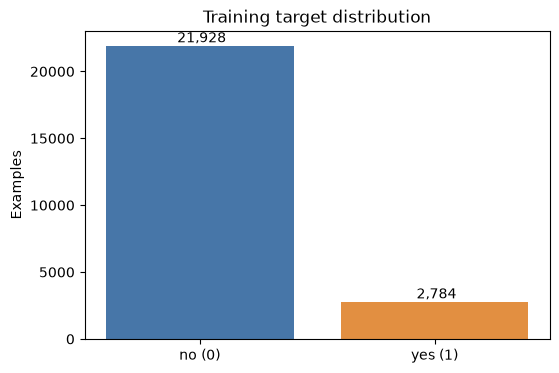

Majority-class proportion: 0.887


In [7]:
# Training target only. No model metric is calculated here.
class_counts = train["subscribed"].value_counts().sort_index()
majority_proportion = class_counts.max() / class_counts.sum()

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(["no (0)", "yes (1)"], class_counts.values, color=["#4776a8", "#e28f41"])
ax.set_title("Training target distribution")
ax.set_ylabel("Examples")
for position, count in enumerate(class_counts.values):
    ax.text(position, count, f" {count:,}", ha="center", va="bottom")
plt.show()
print(f"Majority-class proportion: {majority_proportion:.3f}")

Training literal 'unknown' counts:
default      5188
education    1052
housing       601
loan          601
job           199
marital        50

pdays=999: 23,793 training rows
pdays range when previously contacted: (0, 27)


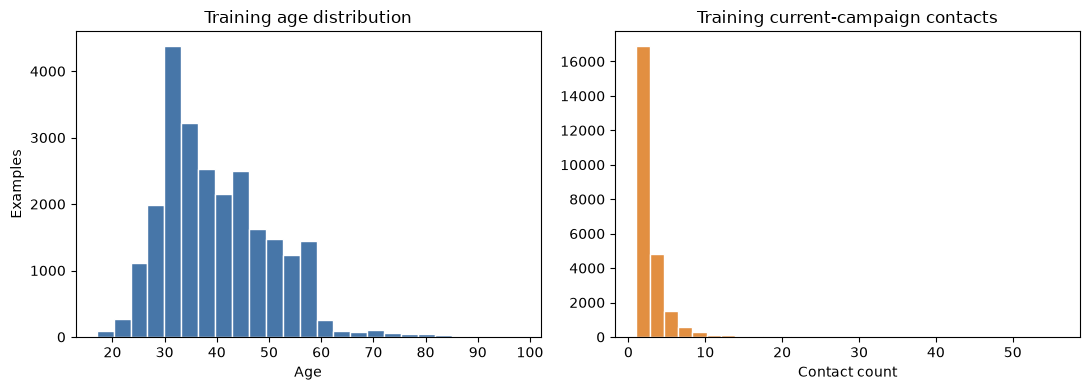

In [8]:
training_unknown_counts = (train == "unknown").sum()
training_unknown_counts = training_unknown_counts[training_unknown_counts > 0].sort_values(ascending=False)
never_contacted_count = int((train["pdays"] == 999).sum())
previously_contacted_pdays = train.loc[train["pdays"] != 999, "pdays"]

print("Training literal 'unknown' counts:")
print(training_unknown_counts.to_string())
print(f"\npdays=999: {never_contacted_count:,} training rows")
print("pdays range when previously contacted:",
      (int(previously_contacted_pdays.min()), int(previously_contacted_pdays.max())))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train["age"], bins=25, color="#4776a8", edgecolor="white")
axes[0].set(title="Training age distribution", xlabel="Age", ylabel="Examples")
axes[1].hist(train["campaign"], bins=30, color="#e28f41", edgecolor="white")
axes[1].set(title="Training current-campaign contacts", xlabel="Contact count")
plt.tight_layout()
plt.show()

### Turn observations into decisions

**STOP — answer from the displayed evidence and source documentation:**

1. Why could accuracy hide the fact that a model fails to find the smaller `yes` class?
2. If every row containing literal `unknown` were deleted, what valid information in the other columns would also be discarded?
3. Why would treating the special code `999` as a measured elapsed time distort `pdays`?
4. The `campaign` histogram has a long right tail: a small number of rows have much larger values. Does that alone prove those values are erroneous? Name at least one check that could justify deletion, such as comparing with source records, checking a documented valid range, or obtaining confirmation from a domain expert.
5. **Preprocessing** cleans or transforms existing data. **Feature engineering** selects inputs or derives a useful input representation. Classify (a) replacing missing numerical `pdays` later with a training median and (b) creating `previously_contacted` from the documented special code.

> **Your answer:**  
> 1. I don't understand the question. What is "accuracy" in this context?
> 2. Obviously, it would delete the record itself, so each row with a single "unknown" value would disappear, and it could contain other valid data for the model training.
> 3. I think that's because the feature itself is numerical and ranges from 0 to 27 in valid cases. Maintaining 999 as a measure of "hasn't been contacted before would warp the numerical average upwards drammatically.
> 4. The only check that comes to mind that could justify deletion is comparing with official bank source records. But the lack of client identifier would render this impossible. At this point I would treat it as being correct or consult with a domain expert if it's mandatory to double check.
> 5. (a) is an act of Preprocessing | (b) is feature engineering.


## 6. Separate a special code from a real measurement

The source uses `pdays` for two different ideas:

- for a previously contacted client, it is the number of days since that contact;
- `999` is a **sentinel value**, meaning “this client was not previously contacted.” It is a code, not a measurement of 999 days.

The lab converts this into two clearer fields. `previously_contacted` is `1` when a previous contact exists and `0` otherwise. For clients with no previous contact, `pdays` becomes a genuine missing numerical value (`NaN`), which the later preprocessing pipeline can replace using a median learned from training data.

Literal `unknown` text in fields such as `job` is handled differently. It remains an explicit category because the fact that the source did not know the value may itself be useful, deleting those rows would discard data, and guessing a job or financial status would invent information.

The section 5 output showed that genuine `pdays` measurements for previously contacted clients range from **0 to 27**. Therefore, zero can already mean a real previous contact with zero elapsed days; it cannot also safely mean “never contacted” unless another field distinguishes the two cases.

**STOP — explain the transformation:** Using the explanation above, describe what happens to `pdays` and `previously_contacted` for (a) a never-contacted client and (b) a previously contacted client. The next code cell implements the stated policy without requiring you to guess internal policy tokens.

> **Your explanation:**  
> a never contacted client would have the "pdays" emptied and therefore becoming "NaN" for pandas and the value "0" under the "previously_contacted" column. A previously contacted client would vice versa have numerical value on pdays and value "1" on the other column. 


In [9]:
# Supplied constants record the policy explained above. Run without edits.
PDAYS_SENTINEL = 999
# `explicit_category` means keeping literal 'unknown' as its own category.
UNKNOWN_POLICY = "explicit_category"

def prepare_semantic_frame(frame):
    prepared = frame.copy()
    prepared["previously_contacted"] = (prepared["pdays"] != PDAYS_SENTINEL).astype("int8")
    prepared["pdays"] = prepared["pdays"].replace(PDAYS_SENTINEL, np.nan)
    return prepared

prepared_train = prepare_semantic_frame(train)
prepared_validation = prepare_semantic_frame(validation)
prepared_test = prepare_semantic_frame(test)

for frame in (prepared_train, prepared_validation, prepared_test):
    assert not (frame["pdays"] == PDAYS_SENTINEL).any()
    assert set(frame["previously_contacted"].unique()) == {0, 1}
    assert frame.loc[frame["previously_contacted"] == 0, "pdays"].isna().all()

print("Semantic transformation applied consistently to all three splits.")

Semantic transformation applied consistently to all three splits.


## 7. Define model inputs and learned preprocessing

The prepared semantic table remains understandable to humans, but the classifier needs numerical inputs. A **categorical feature** represents membership in named groups, such as job type or contact method; arithmetic on those names would not be meaningful. **One-hot encoding** creates a separate 0/1 model column for each category.

In this dataset, `pdays` is the numerical feature with missing values after the section 6 transformation. The numerical pipeline uses `SimpleImputer(strategy="median")`: when the pipeline is fitted, it calculates the median of the non-missing training `pdays` values. It stores that number and uses the same stored number to fill missing `pdays` in training, validation, test, and future operational rows. Validation and test values do not help calculate it.

The next numerical step is **standardization** with `StandardScaler`. For each numerical feature, it learns the training average and typical spread, then expresses values relative to that scale. During training, logistic regression repeatedly adjusts a numerical weight for every input. If the input columns use dramatically different magnitudes, those adjustments can be harder or slower to settle. Standardization puts the inputs on comparable scales. This is the reason scaling is used here; you are not expected to know it in advance.

**STOP — classify the inputs:** Using the displayed data types from section 2, list the ten text-based categorical input columns. Exclude `source_row_id` because it is tracking metadata, and exclude `subscribed` because it is the target. Then summarize, in your own words, the stated reason for standardizing the numerical inputs before logistic regression.

The next cell derives the official list from the training table and prints it so you can compare it with your reasoning; you do not need to reproduce a Python list perfectly.

> **Your categorical list and scaling explanation:**  
> Skipped, the STOP isn't meaningful enough to spend time in doing it. The answer is in the text above anyways.


In [10]:
METADATA_COLUMNS = ["source_row_id"]
TARGET_COLUMN = "subscribed"
FULL_FEATURES = [
    column for column in prepared_train.columns
    if column not in METADATA_COLUMNS + [TARGET_COLUMN]
]
CATEGORICAL_FEATURES = (
    prepared_train[FULL_FEATURES].select_dtypes(exclude="number").columns.tolist()
)
NUMERIC_FEATURES = [column for column in FULL_FEATURES if column not in CATEGORICAL_FEATURES]

assert len(FULL_FEATURES) == 20
assert len(CATEGORICAL_FEATURES) == 10
assert len(NUMERIC_FEATURES) == 10
assert set(FULL_FEATURES) == set(CATEGORICAL_FEATURES) | set(NUMERIC_FEATURES)
assert not set(CATEGORICAL_FEATURES) & set(NUMERIC_FEATURES)
print("Categorical features:", CATEGORICAL_FEATURES)
print("Numerical features:", NUMERIC_FEATURES)

Categorical features: ['job', 'marital', 'education', 'default', 'housing', 'loan', 'contact', 'month', 'day_of_week', 'poutcome']
Numerical features: ['age', 'campaign', 'pdays', 'previous', 'emp_var_rate', 'cons_price_idx', 'cons_conf_idx', 'euribor3m', 'nr_employed', 'previously_contacted']


In [11]:
# Build and inspect the reusable preprocessor. No classifier is evaluated here.
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="constant", fill_value="unknown")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, NUMERIC_FEATURES),
    ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
])

X_train = prepared_train[FULL_FEATURES]
X_validation = prepared_validation[FULL_FEATURES]
y_train = prepared_train[TARGET_COLUMN]

preprocessing_check = clone(preprocessor).fit(X_train)
pdays_position = NUMERIC_FEATURES.index("pdays")
learned_pdays_median = (
    preprocessing_check.named_transformers_["numeric"]
    .named_steps["imputer"].statistics_[pdays_position]
)
transformed_train = preprocessing_check.transform(X_train)
transformed_validation = preprocessing_check.transform(X_validation)

assert transformed_train.shape[0] == len(prepared_train)
assert transformed_validation.shape[0] == len(prepared_validation)
assert transformed_train.shape[1] == transformed_validation.shape[1]
assert not np.isnan(transformed_train.data if hasattr(transformed_train, "data") else transformed_train).any()

print("Semantic input columns:", len(FULL_FEATURES))
print("Transformed model columns learned from training:", transformed_train.shape[1])
print("Median learned from non-missing training pdays:", learned_pdays_median)

Semantic input columns: 20
Transformed model columns learned from training: 63
Median learned from non-missing training pdays: 6.0


### Explain the preprocessing pipeline

The code above names four components. `SimpleImputer` fills missing values; `StandardScaler` centers and scales numerical values; `OneHotEncoder` converts each text category into numerical indicator columns; `ColumnTransformer` sends numerical and categorical columns through the appropriate steps. `Pipeline` chains preprocessing and the later classifier so the same fitted transformations are reused.

`OneHotEncoder(handle_unknown="ignore")` also defines what happens if a later row contains a category not seen during training: the encoder does not create a new model column or fail; for that original feature, all of the already-known category indicator columns are set to zero. This preserves the input shape expected by the fitted classifier, although it does not teach the model the meaning of the new category.

**STOP — connect each behavior to the code:**

1. Which component learns a numerical replacement value?
2. Which component makes numerical magnitudes comparable for logistic regression?
3. Which component converts categories into model inputs?
4. What does `handle_unknown="ignore"` do for an unseen category, and why does preserving the expected number of model columns matter?
5. Why should the whole fitted pipeline be saved instead of only the classifier? Consider how the same median, scales, and category-to-column mapping will be applied later.

> **Your answer:**  
> 1. SimpleImputer
> 2. StandardScaler
> 3. OneHotEncoder
> 4. It defines what happens if a later row containes a category that wasn't previously seen during training.
> 5. This is a good question, and I'm not sure entirely. But I'd imagine it's because during evaluation and tuning maintaining the pipeline will be crucial since the change is currently being applied only to training and validation datasets?


## 8. Map the work to the syllabus activities

This ledger checks whether you can recognize the data-preparation activities from syllabus section 3.2.1. Earlier versions of this task left several statuses open to interpretation. The expected status is now supplied; your task is to connect it to evidence from the work you performed.

- **Performed:** the lab did it or configured it as part of the fitted pipeline.
- **Not performed—not justified here:** the operation is possible in general, but this lab found no evidence-based reason to do it.
- **Not applicable:** the dataset or task gives no reason or object to which that operation could apply.

Use these plain-language meanings when completing the table:

| Activity | Expected status | Meaning and evidence already established |
| --- | --- | --- |
| Data acquisition | Performed | Obtained and verified the labeled source using its hash, schema, and target counts. |
| Cleaning checks | Performed | Inspected exact matches, `unknown` values, the `pdays` code, and numerical ranges; no row deletion was justified. |
| Anonymization/personal-information removal | Not applicable | The published source supplies no client name, client ID, call ID, or other direct identifier to anonymize. The added `source_row_id` is new tracking metadata, not a person's identity. |
| Format transformation | Performed | Renamed columns and encoded the target numerically. |
| Imputation | Performed | Configured and fitted a training-derived median to fill missing `pdays`. |
| Scaling/normalization | Performed | Configured and fitted `StandardScaler` on training numerical features. |
| Augmentation | Not performed—not justified here | No evidence-based need to create synthetic or modified examples was established for this bounded exercise. |
| Sampling | Not performed—not justified here | All rows are retained; splitting assigns roles and is not sampling a smaller working subset to save resources. |
| Feature selection/extraction | Performed | Removed invalid `duration` and derived the clearer `previously_contacted` input. |
| EDA | Performed | Inspected training class counts, special-value counts, ranges, and histograms. |

These activities are not necessarily a one-way sequence. An EDA finding can send you back to cleaning or feature work; new source documentation can change how a field is interpreted; and a changed operational requirement can make an earlier preparation rule unsuitable. The syllabus therefore describes preparation as iterative and says activities may be reordered or omitted according to project needs. The same meanings must still be handled consistently when later operational data is prepared.

**STOP — complete the ledger below:** The statuses are already filled in. For each activity, describe one concrete action, output, or reason in your own words. You are being assessed on recognizing and explaining the activities, not on guessing which status label the exercise author intended.

> **Your activity ledger:**  
> 
> | Activity | Supplied status | Evidence and reason in my own words |
> | --- | --- | --- |
> | Data acquisition | Performed | Retrieved the dataset online |
> | Cleaning checks | Performed | manually inspected data |
> | Anonymization/personal-information removal | Not applicable | No client identifiers |
> | Format transformation | Performed | OneHotEncoder was done on categorical inputs |
> | Imputation | Performed | Done for pdays |
> | Scaling/normalization | Performed | Done for numerical values with StandardScaler |
> | Augmentation | Not performed—not justified here | unknown values were retained due to lack on external information as they are informative as it is |
> | Sampling | Not performed—not justified here | - |
> | Feature selection/extraction | Performed | done for previosly_contacted |
> | EDA | Performed | yep |

## 9. Save the prepared result for later exercises

The code below is supplied scaffolding. It trains one predetermined logistic-regression pipeline on training rows and writes four files for later exercises. An **artifact** is simply a saved output from this lab. A **manifest** is a small JSON record describing what the other files contain, which columns and policies were used, how the split was made, and which software versions created them. It lets a later exercise verify that it received compatible inputs.

The code deliberately makes no predictions and calculates no model metrics.

**STOP — readiness check:** First finish the activity ledger. Then use the list below to describe what each of the four files contributes and explain why the manifest is needed in addition to the data CSV and saved pipeline. Finally, change `I_COMPLETED_THE_ACTIVITY_LEDGER` in the next cell from `False` to `True`.

- `prepared_data.csv`: the human-readable prepared rows;
- `split_assignments.csv`: which row belongs to training, validation, or test;
- `baseline_model.joblib`: the fitted preprocessing plus fixed classifier;
- `manifest.json`: the machine-readable preparation and compatibility record.

> **Your prediction and manifest explanation:**  
> - `prepared_data.csv`: the human-readable prepared rows;
>  - `split_assignments.csv`: which row belongs to training, validation, or test;
>   -  `baseline_model.joblib`: the fitted preprocessing plus fixed classifier;
>   - `manifest.json`: the machine-readable preparation and compatibility record.


In [12]:
I_COMPLETED_THE_ACTIVITY_LEDGER = True  # TODO: change only after writing above
assert I_COMPLETED_THE_ACTIVITY_LEDGER, "Complete the preparation ledger before creating the handoff."

baseline_model = Pipeline([
    ("preprocessor", clone(preprocessor)),
    ("classifier", LogisticRegression(
        solver="lbfgs",
        C=1.0,
        max_iter=2000,
        class_weight=None,
    )),
])
baseline_model.fit(X_train, y_train)

prepared_data = pd.concat(
    [prepared_train, prepared_validation, prepared_test],
    ignore_index=True,
).sort_values("source_row_id")
prepared_data = prepared_data[["source_row_id", *FULL_FEATURES, TARGET_COLUMN]]

split_assignments = pd.concat([
    train[["source_row_id"]].assign(split="train"),
    validation[["source_row_id"]].assign(split="validation"),
    test[["source_row_id"]].assign(split="test"),
], ignore_index=True).sort_values("source_row_id")

assert len(prepared_data) == 41_188
assert prepared_data["source_row_id"].is_unique
assert split_assignments["source_row_id"].is_unique
assert set(prepared_data["source_row_id"]) == set(split_assignments["source_row_id"])
assert "duration" not in prepared_data.columns

ARTIFACTS_DIR = LAB_ROOT / "artifacts"
ARTIFACTS_DIR.mkdir(exist_ok=True)
prepared_path = ARTIFACTS_DIR / "prepared_data.csv"
assignments_path = ARTIFACTS_DIR / "split_assignments.csv"
model_path = ARTIFACTS_DIR / "baseline_model.joblib"
manifest_path = ARTIFACTS_DIR / "manifest.json"

prepared_data.to_csv(prepared_path, index=False, na_rep="")
split_assignments.to_csv(assignments_path, index=False)
joblib.dump(baseline_model, model_path)

manifest = {
    "schema_version": "1.0",
    "source": {
        "dataset": "UCI Bank Marketing",
        "variant": "bank-additional-full.csv",
        "sha256": SOURCE_SHA256,
        "rows": 41_188,
    },
    "prediction_time": PREDICTION_TIME,
    "target": {
        "column": TARGET_COLUMN,
        "raw_mapping": TARGET_MAPPING,
        "positive_class": 1,
    },
    "columns": {
        "metadata": METADATA_COLUMNS,
        "full_features": FULL_FEATURES,
        "categorical_features": CATEGORICAL_FEATURES,
        "numeric_features": NUMERIC_FEATURES,
    },
    "preparation": {
        "excluded_features": {"duration": "unavailable before the scheduled call"},
        "unknown_policy": UNKNOWN_POLICY,
        "pdays_sentinel": PDAYS_SENTINEL,
        "derived_features": ["previously_contacted"],
        "exact_matching_rows_beyond_first": exact_matches_beyond_first,
        "exact_matches_retained": KEEP_EXACT_MATCHES,
    },
    "split": {
        "method": "two stratified train_test_split calls",
        "seed": SPLIT_SEED,
        "proportions": {"train": 0.60, "validation": 0.20, "test": 0.20},
        "sizes": expected_sizes,
        "roles": {
            "train": "fit preprocessing and model parameters",
            "validation": "evaluate baseline and compare development candidates",
            "test": "one final check after HO-3.3.3 selection",
        },
    },
    "baseline_model": {
        "artifact": model_path.name,
        "pipeline_steps": ["preprocessor", "classifier"],
        "classifier": "LogisticRegression",
        "parameters": {
            "solver": "lbfgs", "C": 1.0, "max_iter": 2000, "class_weight": None
        },
        "trained_on": "train",
        "performance_metrics_included": False,
    },
    "versions": {
        "python": platform.python_version(),
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "joblib": joblib.__version__,
    },
}
manifest_path.write_text(json.dumps(manifest, indent=2) + "\n", encoding="utf-8")

trusted_reload = joblib.load(model_path)
assert list(trusted_reload.named_steps) == ["preprocessor", "classifier"]
for artifact_path in [prepared_path, assignments_path, model_path, manifest_path]:
    assert artifact_path.exists() and artifact_path.stat().st_size > 0
    print(f"Created {artifact_path.relative_to(LAB_ROOT)}")
print("Baseline trained and saved. No validation or test predictions were made.")

Created artifacts\prepared_data.csv
Created artifacts\split_assignments.csv
Created artifacts\baseline_model.joblib
Created artifacts\manifest.json
Baseline trained and saved. No validation or test predictions were made.


## Completion checkpoint

You are finished with the notebook when you can do all of these without reading code line by line:

- [x] Point to evidence for every preparation decision.
- [x] Distinguish literal missing-information categories, numerical missing values, and sentinels.
- [x] Explain why `duration` is invalid despite being predictive.
- [x] Explain why learned preprocessing was fitted on training rows only.
- [x] Map the work to acquisition, preprocessing, feature engineering, and EDA.
- [x] Confirm that all four handoff artifacts exist.
- [x] State that model quality has not yet been evaluated.

Now close or minimize the notebook and complete `learning_log.md` from memory. Return here only afterward to correct specific gaps. The next exercise may use validation data to calculate performance metrics; the test set remains sealed until the final model/dataset comparison exercise.